In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Olharemos homicídios Dolosos
1. Saber se existe BPM com muitos homicidios dolosos
2. Verificar se há uma média de hom dolosos através dos BPMS
3. Fazer uma visualização dos que estão muito acima dos demais 
4. Caso não haja muito acima dos demais, mostrar ranking de todos os BPMS
5. Mostre métricas de que sustente que a média é confiável

In [9]:
try:
    df_ocorrencias = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding='iso-8859-1')

    df_bpm = pd.read_csv('08.BPM.csv', sep=';', encoding='utf-8')

    # print(df_ocorrencias.info())
    # print(df_bpm.info())
    # merge: 
    # left_on -> qual coluna da tabela da esquerda vai ser o indice para juntar com a direita
    # Right_on -> qual coluna da tabela da direita vai ser o indice para juntar com a esquerda
    # How -> jeito que vai juntar as duas colunas:
    # How = right -> pega tudo da direita e copia o que tem combinação da esquerda
    # How = left -> pega tudo da esquerda  e copia o que tem combinação da direita
    # How = inner -> pega só o que tem cobinação entre as duas tabelas (colunas)
    # How = outer -> pega tudo das duas tabelas

    df_merge = df_ocorrencias.merge(df_bpm, left_on='aisp', right_on='COD_BPM', how='left')

    df_doloso = df_merge [['aisp','NM_BPM', 'hom_doloso']]
        
    df_doloso.fillna('BPM não encontrado', inplace=True)

    df_doloso_agrupado = df_doloso.groupby(['aisp' , 'NM_BPM']).sum().reset_index()

    print(df_doloso_agrupado)

    # fillna -> preenche as lacunas deixadas por inconsistências de junção

    # df_merge['COD_BPM'] = df_merge['COD_BPM'].astype(str)

    # df_merged.info()

    # df_merged.fillna('BPM não encontrada', inplace=True)

except Exception as e:
    print(f'Erro ao importar dados: {e}')

    aisp              NM_BPM  hom_doloso
0      1  BPM não encontrado         634
1      2              2º BPM         343
2      3              3º BPM        2624
3      4              4º BPM         780
4      5              5º BPM         723
5      6              6º BPM         794
6      7              7º BPM        7087
7      8              8º BPM        4495
8      9              9º BPM        5889
9     10             10º BPM        1082
10    11             11º BPM         953
11    12             12º BPM        3444
12    13  BPM não encontrado         108
13    14             14º BPM        4605
14    15             15º BPM        8474
15    16             16º BPM        2167
16    17             17º BPM         806
17    18             18º BPM        2184
18    19             19º BPM         193
19    20             20º BPM       10696
20    21             21º BPM        3278
21    22             22º BPM        1922
22    23             23º BPM         420
23    24        

In [10]:
# CALCULAR MÉTRICAS -> DISPERSÃO

doloso_array = np.array(df_doloso_agrupado['hom_doloso'])

q1 = np.quantile(doloso_array, 0.25)
q2 = np.quantile(doloso_array, 0.5)
q3 = np.quantile(doloso_array, 0.75)

media = np.mean(doloso_array)

desvio = np.std(doloso_array)

cv = desvio/media

delta = media/q2


In [15]:
# preparação para o gráfico

iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

# filtrar outliers

df_doloso_outliers_sup = df_doloso_agrupado[df_doloso_agrupado['hom_doloso'] > limite_sup]

df_grafico = None

if df_doloso_outliers_sup.empty:
    df_grafico = df_doloso_agrupado.sort_values(by='hom_doloso', ascending=False)
    print(f'1. Não há BPMS com número de homicídios dolosos muito maior que os outros')

else:
    df_grafico = df_doloso_outliers_sup
    print(f'1. Existem {df_doloso_outliers_sup.shape[0]} BPMS com números de homicídios dolosos')

1. Existem 2 BPMS com números de homicídios dolosos


2. Média de homicídios dolosos: 2496.10
5. Mediana: 2175.50
5. Delta Media/Mediana : 1.15
5. Desvio padrão: 2373.29
5. Coeficiente de variação: 95.08%


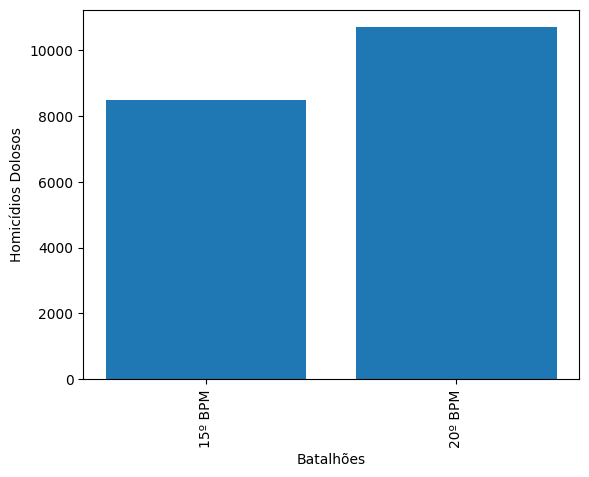

In [21]:
print(f'2. Média de homicídios dolosos: {media:.2f}')
print(f'5. Mediana: {q2:.2f}')
print(f'5. Delta Media/Mediana : {delta:.2f}')
print(f'5. Desvio padrão: {desvio:.2f}')
print(f'5. Coeficiente de variação: {cv*100:.2f}%')

plt.bar(df_grafico['NM_BPM'], df_grafico['hom_doloso'])
plt.xticks(rotation=90)
plt.xlabel('Batalhões')
plt.ylabel('Homicídios Dolosos')
plt.show()